In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
from scipy.spatial.distance import cdist
from itertools import product

# Trajectories + Transition dipole moments dataframe

In [3]:
data = pd.read_csv("trajs-dataframe-pc.csv")
data

,TRAJ,Time,x1,y1,z1,x2,y2,z2,x3,y3,...,z23,x24,y24,z24,mu_x,mu_y,mu_z,mu_x_pc,mu_y_pc,mu_z_pc
0,1,0.5,-0.903948,2.567011,0.066012,1.375391,1.360069,-0.122150,0.848979,0.165433,...,0.206331,-4.208275,-0.299556,-0.045503,-1.298255,0.060673,-0.002043,-1.298255,0.060673,-0.002043
1,1,1.0,-0.903835,2.562395,0.065014,1.380791,1.361061,-0.124760,0.841877,0.155487,...,0.193118,-4.222286,-0.319823,-0.051924,1.330744,-0.063285,0.004413,-1.330744,0.063285,-0.004413
2,1,1.5,-0.903613,2.557535,0.064056,1.385793,1.362369,-0.127433,0.834433,0.145367,...,0.180662,-4.265446,-0.344548,-0.060105,-1.377839,0.065160,-0.006069,-1.377839,0.065160,-0.006069
3,1,2.0,-0.903245,2.552448,0.063149,1.390274,1.363923,-0.130158,0.826782,0.135235,...,0.169053,-4.328030,-0.371130,-0.069135,1.431230,-0.067969,0.006861,-1.431230,0.067969,-0.006861
4,1,2.5,-0.902709,2.547157,0.062301,1.394119,1.365663,-0.132925,0.819068,0.125243,...,0.158393,-4.399876,-0.396572,-0.077975,1.484248,-0.072878,0.006718,-1.484248,0.072878,-0.006718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,215,98.0,-0.934367,2.541373,0.038740,1.475924,1.438822,0.065239,0.778559,0.125982,...,0.018664,-4.513288,-0.037115,-0.031534,-1.884159,0.072271,-0.012103,-1.884159,0.072271,-0.012103
42996,215,98.5,-0.930888,2.543931,0.038357,1.476764,1.435126,0.065179,0.778242,0.132994,...,0.006837,-4.498413,-0.056363,-0.037674,1.861778,-0.057815,0.010398,-1.861778,0.057815,-0.010398
42997,215,99.0,-0.927550,2.546153,0.037961,1.477164,1.430590,0.064979,0.778772,0.140455,...,-0.004734,-4.487472,-0.077722,-0.043962,-1.829654,0.037963,-0.008759,-1.829654,0.037963,-0.008759
42998,215,99.5,-0.924355,2.548018,0.037551,1.477064,1.425246,0.064641,0.780161,0.148247,...,-0.015892,-4.482751,-0.100842,-0.050284,1.787543,-0.012123,0.007323,-1.787543,0.012123,-0.007323


# Geometries

## Translational invariance

Given our initial geometries dataset, we would like to encode one essential physical symmetry feature, namely **translational invariance**.<br>
Indeed, two geometries differing only by a translation (equally applied to each atom) in our Cartesian reference frame, should be seen as equal inputs by the ML model. <br>
Therefore, the ML model is expected to produce the same output $\mu^{pred}$.

We extract our geometries array from the previous dataframe, ranging from **x1** to **z24**.

In [5]:
# number of atoms in HBQ molecule
nat = 24
final_column = 2 + (nat * 3)

arr = data.iloc[:, 2:final_column].to_numpy()
geoms = arr.reshape(-1, 24, 3)
geoms.shape

(43000, 24, 3)

For our procedure, we need the nuclear masses list of HBQ molecule, which we picked from the **/TRAJ1/geom** file, <br>
from NewtonX **TRAJECTORIES** folder.

In [7]:
masses = np.loadtxt("geom", usecols=(-1,))
masses.shape

(24,)

Masses are in A.M.U., but any unit system would be good, because they simplify out in our procedure.

In [8]:
masses

array([15.99491464, 14.00307401, 12.        , 12.        , 12.        ,
       12.        , 12.        , 12.        , 12.        , 12.        ,
       12.        , 12.        , 12.        , 12.        , 12.        ,
        1.00782504,  1.00782504,  1.00782504,  1.00782504,  1.00782504,
        1.00782504,  1.00782504,  1.00782504,  1.00782504])

In the following, we encode translational invariance according to this:
1. Compute C.O.M. (center of mass) for each geometry, store in array.
2. Express each geometry in its C.O.M. coordinates, i.e. the C.O.M. is the new origin. 

In [9]:
# Array with centres of mass for all geoms

def allcom(geoms):
    coms = np.zeros((len(geoms), 3))
    for i in range(len(geoms)):
        num, den = 0, 0
        for j in range(geoms.shape[1]):
            num = num + (masses[j] * geoms[i, j])
            den = den + masses[j]
        coms[i] = num / den
    return coms

allcom(geoms).shape

(43000, 3)

In [10]:
# Translate geometries

geoms_transl = np.zeros(geoms.shape)

def translateg(geoms, geoms_com):
    for i in range(len(geoms)):
        for j in range(geoms.shape[1]):
            geoms_transl[i, j] = geoms[i, j] - geoms_com[i]
    return geoms_transl

translateg(geoms, allcom(geoms)).shape

(43000, 24, 3)

Finally, here is our geometries dataset encoding translational invariance, <br>
conveniently stored in a Numpy array.

In [11]:
geomst = translateg(geoms, allcom(geoms))

# Descriptors

Here we define the descriptors used in the ML model. <br>
So far:
- Coulomb matrix

## Coulomb matrix descriptor

We need the nuclear charges list of HBQ molecule, which we picked from the **/TRAJ1/geom** file, <br>
from NewtonX **TRAJECTORIES** folder.

In [13]:
nuc_charges = np.loadtxt("geom", usecols=(1,))
nuc_charges.shape

(24,)

In [14]:
# Coulomb matrix

nat = len(nuc_charges)
ngeoms = len(geoms)
C = np.zeros((ngeoms, nat, nat))

def coulomb_matrix(geoms_array, nuc_charges):
    for g, geom in enumerate(geoms_array):
        for i in range(nat):
            C[g, i, i] = ((nuc_charges[i])**(2.4)) / 2
            
            for j in range(i):
                C[g, i, j] = (nuc_charges[i] * nuc_charges[j]) / np.linalg.norm(geom[i] - geom[j])
                C[g, j, i] = C[g, i, j]
    return C

In [15]:
# apply Coulomb matrix

C1 = coulomb_matrix(geomst, nuc_charges)
C1.shape

(43000, 24, 24)

In [16]:
# flattened C1 array to be passed as features
# only lower triangular part is included because of simmetry

i_lower = np.tril_indices(nat, k=0) # include the diagonal
C1_flat = np.array([cm[i_lower] for cm in C1])
C1_flat.shape

(43000, 300)

We can print the 1st Coulomb matrix in the C1 array, as an example.

In [17]:
# check

import pandas as pd

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

atom_labels = np.array(['O', 'N'] + 13*['C'] + 9*['H'])

df = pd.DataFrame(C1[0], index=atom_labels, columns=atom_labels)
df

,O,N,C,C,C,C,C,C,C,C,C,C,C,C,C,H,H,H,H,H,H,H,H,H
O,73.52,21.65,16.13,19.69,10.87,12.76,9.15,9.83,35.54,9.19,11.34,12.90,20.27,9.86,13.33,1.27,1.39,7.69,1.28,1.52,2.09,2.99,1.38,1.83
N,21.65,53.36,32.14,18.12,17.46,11.54,11.24,10.37,15.08,15.14,8.73,32.31,9.93,18.12,8.49,1.50,1.38,4.23,1.83,1.23,3.80,1.42,2.13,1.20
C,16.13,32.14,36.86,24.83,24.94,14.55,14.31,13.12,14.21,14.93,9.53,15.89,9.37,13.45,8.54,1.71,1.59,2.53,1.78,1.31,1.98,1.27,1.59,1.18
C,19.69,18.12,24.83,36.86,14.11,24.47,12.28,14.68,25.40,9.55,14.42,10.17,14.48,8.75,13.00,1.51,1.80,2.52,1.30,1.75,1.44,1.74,1.15,1.65
C,10.87,17.46,24.94,14.11,36.86,12.44,23.87,15.03,9.32,26.16,8.36,13.15,7.15,15.11,7.04,2.62,1.79,1.59,2.87,1.23,1.65,1.00,1.78,1.01
C,12.76,11.54,14.55,24.47,12.44,36.86,14.66,25.67,14.38,8.44,25.45,7.60,12.45,7.19,14.95,1.78,2.96,1.56,1.23,2.82,1.10,1.53,0.99,1.93
C,9.15,11.24,14.31,12.28,23.87,14.66,36.86,27.51,8.28,14.03,9.67,8.49,6.93,9.43,7.40,5.68,2.97,1.24,2.17,1.49,1.17,0.97,1.27,1.08
C,9.83,10.37,13.12,14.68,15.03,25.67,27.51,36.86,9.60,9.76,14.53,7.39,8.40,7.57,9.67,2.95,5.80,1.27,1.49,2.21,1.05,1.13,1.04,1.39
C,35.54,15.08,14.21,25.40,9.32,14.38,8.28,9.60,36.86,7.28,12.48,8.83,24.93,7.24,15.05,1.11,1.33,3.18,1.02,1.54,1.35,2.70,1.00,1.86
C,9.19,15.14,14.93,9.55,26.16,8.44,14.03,9.76,7.28,36.86,6.34,14.91,5.78,24.92,5.59,2.05,1.32,1.37,5.62,0.96,1.84,0.84,2.75,0.83


# Tdm

We extract the phase-corrected transition dipole moments (see Notebook_1_1 for reference of the procedure) <br>
from the dataframe.

In [19]:
transition = data.iloc[:, -3:]
transition

,mu_x_pc,mu_y_pc,mu_z_pc
0,-1.298255,0.060673,-0.002043
1,-1.330744,0.063285,-0.004413
2,-1.377839,0.065160,-0.006069
3,-1.431230,0.067969,-0.006861
4,-1.484248,0.072878,-0.006718
...,...,...,...
42995,-1.884159,0.072271,-0.012103
42996,-1.861778,0.057815,-0.010398
42997,-1.829654,0.037963,-0.008759
42998,-1.787543,0.012123,-0.007323


In [29]:
tdm = transition.to_numpy()

tdm.shape

(43000, 3)

# Dataset choice

In [30]:
# randomly pick 1000 tdm + associated Coulomb matrices from the 215 TRAJS 

# pick a reproducible set of 1000 indices in range 0 - 42999
rng = np.random.default_rng(42)
indices = rng.choice(tdm.shape[0], size=1000, replace=False)

random_tdm_sample = tdm[indices]
random_coulomb_sample = C1_flat[indices]

random_tdm_sample.shape, random_coulomb_sample.shape

((1000, 3), (1000, 300))

# KRR model

- KRR
- Gaussian kernel
- Coulomb matrix descriptor

In [31]:
# train / val / test split
n_sample = len(random_tdm_sample)

# split dataset into working and test
frac_work = 0.8
idx_work = int(frac_work * n_sample)

X_working, Y_working = random_coulomb_sample[:idx_work], random_tdm_sample[:idx_work]
X_test, Y_test = random_coulomb_sample[idx_work:], random_tdm_sample[idx_work:]

# split working into sub and val
frac_sub = 0.8
idx_sub = int(frac_sub * idx_work)

X_sub, Y_sub = X_working[:idx_sub], Y_working[:idx_sub]
X_val, Y_val = X_working[idx_sub:], Y_working[idx_sub:]

In [32]:
def gaussian_kernel(A, B, sigma):
    sq_dists = cdist(A, B, metric='sqeuclidean')
    return np.exp(-(sq_dists) / (2 * sigma**2))

In [33]:
# Function definitions

def krr_train(X, Y, sigma, lam):
    K = gaussian_kernel(X, X, sigma)
    np.fill_diagonal(K, K.diagonal() + lam) # add lam to diagonal for regularization
    
    alphas = np.linalg.solve(K, Y)
    return alphas

def krr_predict(X_sub, X_val, alphas, sigma):
    K = gaussian_kernel(X_val, X_sub, sigma)
    return K @ alphas

def rmse(Y_pred, Y_ref):
    return np.sqrt(np.mean((Y_pred - Y_ref)**2))

# initialize hyperparameters ranges and best values
sigmas  = 2.0 ** np.arange(-5, 10)
lambdas = 2.0 ** np.arange(-35, 1)
best_rmse_val, best_sigma, best_lam = np.inf, None, None

# grid-search best hyperparams based on least RMSE 
def opt_grid_search(sigmas, lambdas, best_rmse_val, best_sigma, best_lam):
    for sigma, lam in product(sigmas, lambdas):
        alphas = krr_train(X_sub, Y_sub, sigma, lam)
        Y_pred = krr_predict(X_sub, X_val, alphas, sigma)
        rmse_val = rmse(Y_pred, Y_val)
        
        if rmse_val < best_rmse_val:
            best_rmse_val, best_sigma, best_lam = rmse_val, sigma, lam

    print(f"Optimal sigma={best_sigma:.4f}, lambda={best_lam:.2e}")
    print(f"Best validation RMSE = {best_rmse_val:.4f}")

    return best_rmse_val, best_sigma, best_lam

In [34]:
# Optimize hyperparameters

best_rmse_val, best_sigma, best_lam = opt_grid_search(sigmas, lambdas, best_rmse_val, best_sigma, best_lam)

Optimal sigma=16.0000, lambda=9.77e-04
Best validation RMSE = 0.0493


In [35]:
# Train on working using optimal parameters

final_alphas = krr_train(X_working, Y_working, best_sigma, best_lam)

In [36]:
# Evaluate on test using the final alphas

Y_pred_test = krr_predict(X_working, X_test, final_alphas, best_sigma)

print("\nTest set performance:")
for i, comp in enumerate(['x', 'y', 'z']):
    print(f"  RMSE µ_{comp} = {rmse(Y_pred_test[:, i], Y_test[:, i]):.4f}")
print(f"  RMSE global  = {rmse(Y_pred_test, Y_test):.4f}")


Test set performance:
  RMSE µ_x = 0.0575
  RMSE µ_y = 0.0456
  RMSE µ_z = 0.0269
  RMSE global  = 0.0451


# Metrics

## Correlation plots

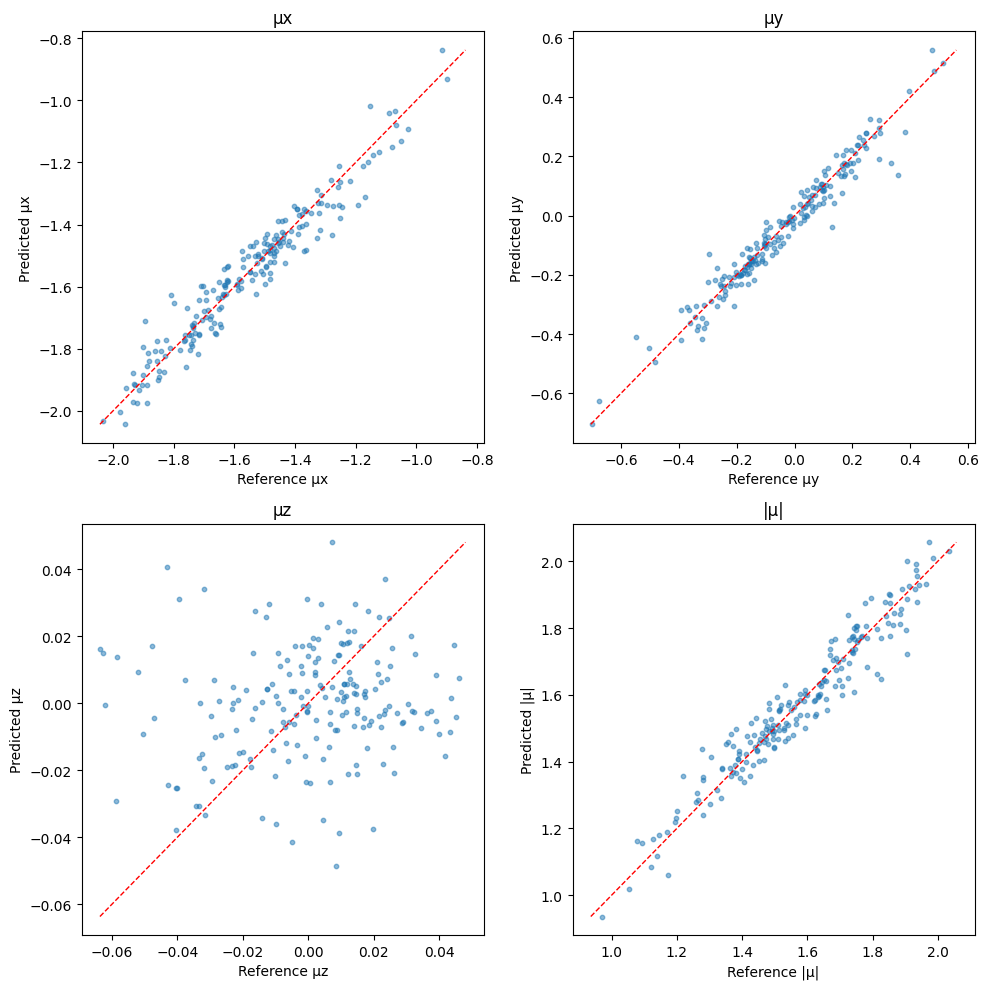

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
labels = ['µx', 'µy', 'µz', '|µ|']

Y_norm_test  = np.linalg.norm(Y_test, axis=1)
YP_norm_test = np.linalg.norm(Y_pred_test, axis=1)

for i, (ax, lab) in enumerate(zip(axes.flatten(), labels)):
    if i < 3:
        ref  = Y_test[:, i]
        pred = Y_pred_test[:, i]
    else:
        ref  = Y_norm_test
        pred = YP_norm_test
    ax.scatter(ref, pred, alpha=0.5, s=10)
    lims = [min(ref.min(), pred.min()), max(ref.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=1)   # ideal diagonal
    ax.set_xlabel(f'Reference {lab}')
    ax.set_ylabel(f'Predicted {lab}')
    ax.set_title(lab)

plt.tight_layout()

## Error distribution

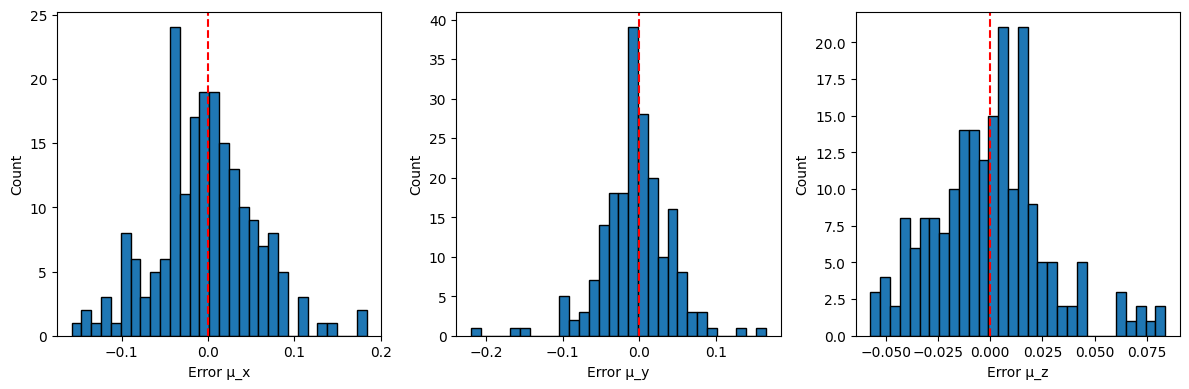

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (ax, comp) in enumerate(zip(axes, ['x', 'y', 'z'])):
    residuals = Y_pred_test[:, i] - Y_test[:, i]
    ax.hist(residuals, bins=30, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel(f'Error µ_{comp}')
    ax.set_ylabel('Count')
plt.tight_layout()

## Error vs TDM magnitude 

Text(0.5, 1.0, 'Error vs TDM magnitude')

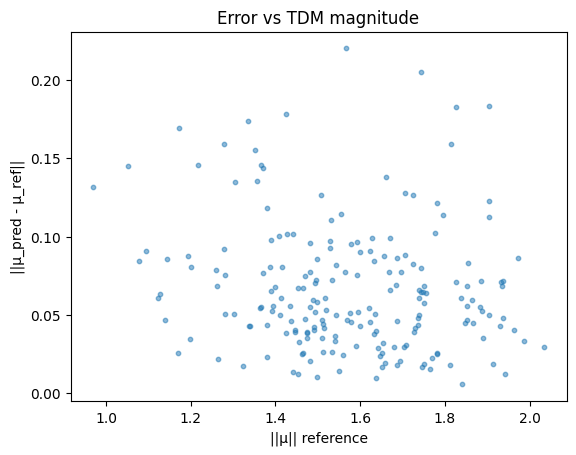

In [39]:
norms = np.linalg.norm(Y_test, axis=1)
errs  = np.linalg.norm(Y_pred_test - Y_test, axis=1)

plt.scatter(norms, errs, alpha=0.5, s=10)
plt.xlabel('||µ|| reference')
plt.ylabel('||µ_pred - µ_ref||')
plt.title('Error vs TDM magnitude')